# Lista 3 - Visão Computacional
Alunos: José Matheus Santana Alves e Ycaro Bruno Souza Sales

In [11]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## Questão 1

## Questão 2

In [ ]:
pts = []

def selecionar_pontos(event, x, y, flags, param):
    global pts
    if event == cv.EVENT_LBUTTONUP:
        cv.circle(img_soccer, (x, y), 2, (0, 0, 255), -1)
        pts.append([x, y])
        print(f"Ponto registrado: {x, y} - Total: {len(pts)}/4")

img_soccer = cv.imread('soccer.jpg')
img_original = img_soccer.copy()
largura_maxima = 1400
escala_redimensionamento = largura_maxima / img_soccer.shape[1]
nova_altura = int(img_soccer.shape[0] * escala_redimensionamento)
img_soccer = cv.resize(img_soccer, (largura_maxima, nova_altura))

cv.namedWindow('Selecione as quinas da Grande Area')
cv.setMouseCallback('Selecione as quinas da Grande Area', selecionar_pontos)

print("1. Quina Inferior da Área Esquerda")
print("2. Quina Inferior da Área Direita")
print("3. Quina Superior da Área Esquerda")
print("4. Quina Superior da Área Direita")

while True:
    cv.imshow('Selecione as quinas da Grande Area', img_soccer)
    k = cv.waitKey(20) & 0xFF
    if k == 27:
        if len(pts) == 4:
            break

cv.destroyAllWindows()

escala = 10

largura_campo = 105
altura_campo = 68

x_esquerdo = 16.5
x_direito = largura_campo - 16.5 
y_inferior = (altura_campo - 40.32) / 2 
y_superior = y_inferior + 40.32 


y_inf_cv = (altura_campo - y_inferior) * escala
y_sup_cv = (altura_campo - y_superior) * escala
x_esq_cv = x_esquerdo * escala
x_dir_cv = x_direito * escala

pts_mapa = np.float32([
    [x_esq_cv, y_inf_cv], # 1. Inferior Esquerdo
    [x_dir_cv, y_inf_cv], # 2. Inferior Direito
    [x_esq_cv, y_sup_cv], # 3. Superior Esquerdo
    [x_dir_cv, y_sup_cv]  # 4. Superior Direito
])

pts = np.float32(pts)


H, mask = cv.findHomography(pts, pts_mapa, cv.RANSAC, 5.0)


pts_original = pts / escala_redimensionamento
H_alta_res, mask2 = cv.findHomography(pts_original, pts_mapa, cv.RANSAC, 5.0)

dimensao_imagem_final = (largura_campo * escala, altura_campo * escala)
mapa_2d = cv.warpPerspective(img_original, H_alta_res, dimensao_imagem_final)

nome_arquivo = 'campo_mapa_area.png'
cv.imwrite(nome_arquivo, mapa_2d)

1. Quina Inferior da Área Esquerda
2. Quina Inferior da Área Direita
3. Quina Superior da Área Esquerda
4. Quina Superior da Área Direita
Ponto registrado: (353, 367) - Total: 1/4
Ponto registrado: (641, 701) - Total: 2/4
Ponto registrado: (756, 313) - Total: 3/4
Ponto registrado: (1124, 615) - Total: 4/4


True

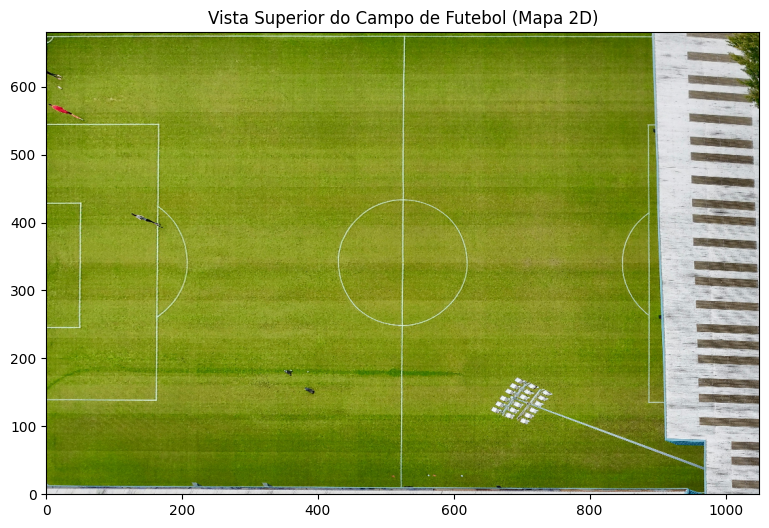

In [26]:
mapa_2d = cv.imread("campo_mapa_area.png")
mapa_2d_rgb = cv.cvtColor(mapa_2d, cv.COLOR_BGR2RGB)

altura, largura = mapa_2d_rgb.shape[:2]

plt.figure(figsize=(10, 6)) 
plt.imshow(mapa_2d_rgb, extent=[0, largura, 0, altura])
plt.title('Vista Superior do Campo de Futebol (Mapa 2D)')



plt.show()

In [ ]:
pts_selecionados = []
altura = mapa_2d.shape[0]

def capturar_clique(event, x, y, flags, param):
    global pts_selecionados
    
    if event == cv.EVENT_LBUTTONDOWN:
        y_invertido = altura - y
        pts_selecionados.append((x, y_invertido))
        print(f"Ponto {len(pts_selecionados)} selecionado: X={x}, Y={y_invertido}")
        
        cv.circle(mapa_2d, (x, y), 5, (255, 0, 0), -1)
        cv.imshow('Selecione 2 pontos', mapa_2d)

cv.namedWindow('Selecione 2 pontos', cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Selecione 2 pontos', capturar_clique)

while True:
    cv.imshow('Selecione 2 pontos', mapa_2d)
    
    k = cv.waitKey(20) & 0xFF
    if k == 27:
        print("Operação cancelada")
        break
    
    if len(pts_selecionados) == 2:
        cv.waitKey(500)
        break

cv.destroyAllWindows()

if len(pts_selecionados) == 2:
    print("\n--- Resultado ---")
    print(f"Ponto 1: {pts_selecionados[0]}")
    print(f"Ponto 2: {pts_selecionados[1]}")

Ponto 1 selecionado: X=19, Y=616
Ponto 2 selecionado: X=55, Y=553

--- Resultado ---
Ponto 1: (19, 616)
Ponto 2: (55, 553)


## Questão 3

## Questão 4